In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/cleaned_ri_matches.csv')

print("Dataset Overview:")
print(f"Total rows: {len(df)}")
print(f"Unique award names: {df['awardname'].nunique()}")
print(f"Year range: {df['awardreceivedawardyear'].min()} to {df['awardreceivedawardyear'].max()}")
print(f"Prestige levels: {', '.join(df['prestige'].unique())}")
print("\n")

common_awards = df['awardname'].value_counts()
common_awards = common_awards[common_awards >= 10]
print(f"Number of awards appearing 10+ times: {len(common_awards)}")

award_prestige = pd.crosstab(
    df[df['awardname'].isin(common_awards.index)]['awardname'], 
    df[df['awardname'].isin(common_awards.index)]['prestige'],
    normalize='index'
)

print("\nTop 5 awards most likely to be 'Highly Prestigious':")
print(award_prestige.sort_values('Highly Prestigious', ascending=False).head(5)['Highly Prestigious'])

print("\nTop 5 awards most likely to be 'Prestigious':")
print(award_prestige.sort_values('Prestigious', ascending=False).head(8)['Prestigious'])

Dataset Overview:
Total rows: 2403
Unique award names: 949
Year range: 1900 to 2025
Prestige levels: Not Designated, Prestigious, Highly Prestigious


Number of awards appearing 10+ times: 31

Top 5 awards most likely to be 'Highly Prestigious':
awardname
NEH Fellowships for University Teachers                                                                                 1.000000
American Academy of Arts and Sciences Member/Fellow                                                                     1.000000
ACLS Fellows (ACLS/SSRC/NEH International and Area Studies Fellowships and ACLS/New York Public Library Fellowships)    1.000000
Guggenheim Fellowship                                                                                                   1.000000
Fellow                                                                                                                  0.033708
Name: Highly Prestigious, dtype: float64

Top 5 awards most likely to be 'Prestigious':
awardname
A


Keyword patterns in award names:
  keyword  count  avg_prestige
4   Medal     16      0.687500
0  Fellow    828      0.497585
2   Prize     95      0.368421
1   Award    704      0.129261
3   Grant    177      0.062147


Text(0, 0.5, 'Avg Prestige Score (0-2)')

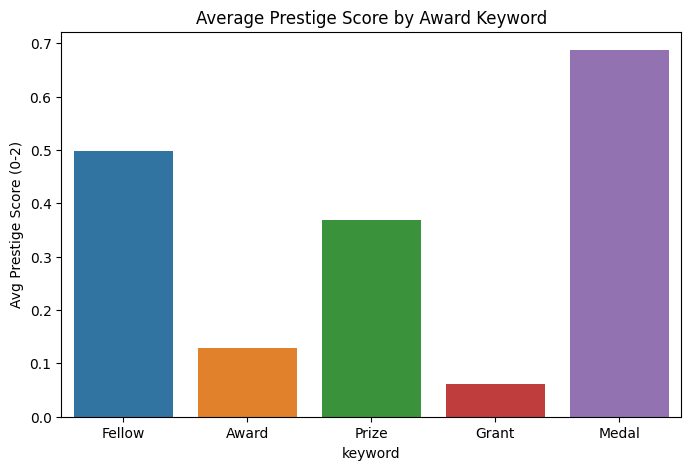

In [36]:
prestige_map = {
    'Not Designated': 0, 
    'Prestigious': 1, 
    'Highly Prestigious': 2
}
df['prestige_score'] = df['prestige'].map(prestige_map)

yearly_prestige = df.groupby('awardreceivedawardyear')['prestige_score'].agg(['mean', 'count'])
yearly_prestige = yearly_prestige[yearly_prestige['count'] >= 10]

keywords = ["Fellow", "Award", "Prize", "Grant", "Medal"]
keyword_results = []

for keyword in keywords:
    keyword_rows = df[df['awardname'].str.contains(keyword, case=False)]
    avg_prestige = keyword_rows['prestige_score'].mean()
    keyword_results.append({
        'keyword': keyword,
        'count': len(keyword_rows),
        'avg_prestige': avg_prestige
    })

keyword_df = pd.DataFrame(keyword_results)
print("\nKeyword patterns in award names:")
print(keyword_df.sort_values('avg_prestige', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='keyword', y='avg_prestige', data=keyword_df)
plt.title('Average Prestige Score by Award Keyword')
plt.ylabel('Avg Prestige Score (0-2)')

Awards with Signficant Changes Over Time

In [37]:
award_counts = df['awardname'].value_counts()
common_awards = award_counts[award_counts >= 10].index.tolist()

df['decade'] = df['awardreceivedawardyear'].apply(
    lambda year: 'pre-1980' if year == 1900 or year < 1980 
    else f"{(year // 10) * 10}s"
)

df_common = df[df['awardname'].isin(common_awards)]

decades = sorted(df_common['decade'].unique())
trend_decades = [d for d in decades if d != 'pre-1980']


significant_awards = award_counts[award_counts >= 20].index.tolist()

award_trends = {}
for award in significant_awards:
    decade_data = []
    
    for decade in trend_decades:
        decade_df = df_common[df_common['decade'] == decade]
        total_in_decade = len(decade_df)
        award_in_decade = len(decade_df[decade_df['awardname'] == award])
        
        if award_in_decade > 0 and total_in_decade > 0:
            percentage = (award_in_decade / total_in_decade) * 100
            decade_data.append({
                'decade': decade,
                'count': award_in_decade,
                'percentage': percentage
            })
    
    if len(decade_data) >= 3:
        first = decade_data[0]
        last = decade_data[-1]
        trend = last['percentage'] - first['percentage']
        
        award_trends[award] = {
            'award': award,
            'trend': trend,
            'first_decade': first['decade'],
            'last_decade': last['decade'],
            'first_percentage': f"{first['percentage']:.1f}%",
            'last_percentage': f"{last['percentage']:.1f}%",
            'decade_data': decade_data
        }

sorted_trends = sorted(award_trends.values(), key=lambda x: abs(x['trend']), reverse=True)

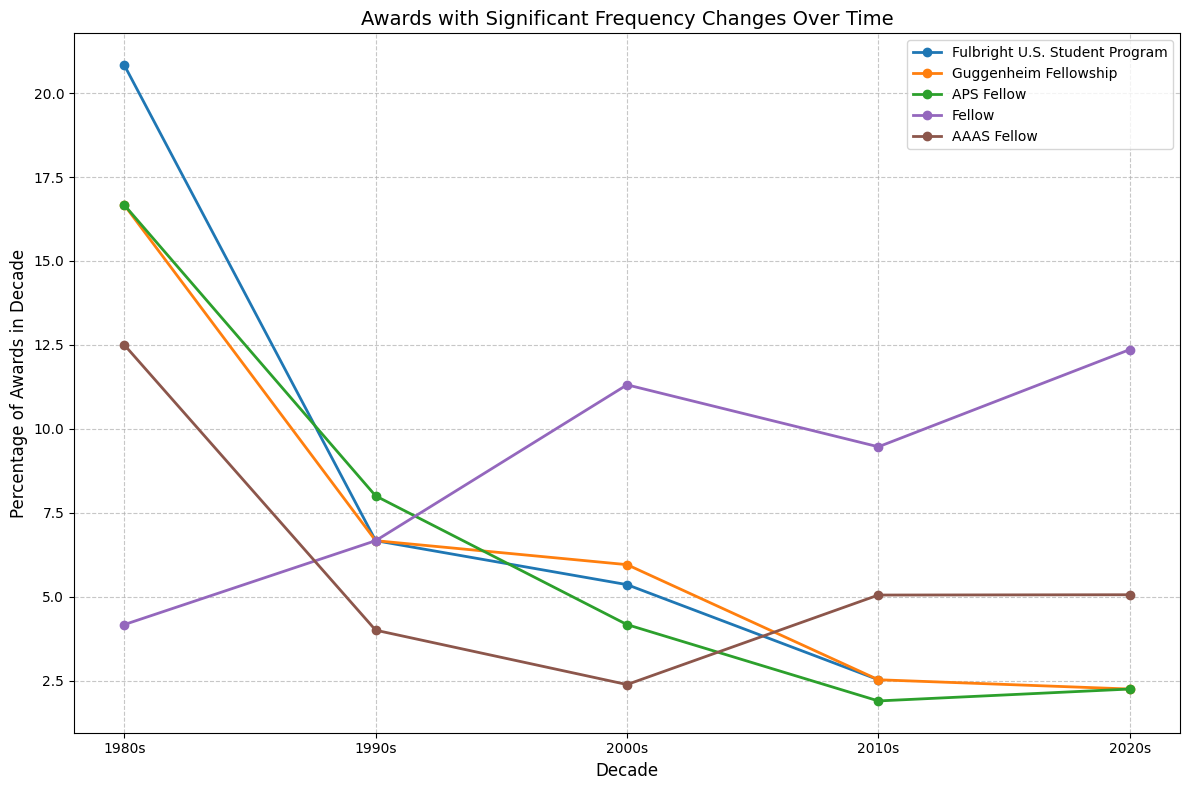

In [38]:
plt.figure(figsize=(12, 8))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for i, item in enumerate(sorted_trends[:5]):
    decades_list = [d['decade'] for d in item['decade_data']]
    percentages = [d['percentage'] for d in item['decade_data']]
    
    plt.plot(decades_list, percentages, marker='o', linewidth=2, color=colors[i], label=item['award'])

plt.title("Awards with Significant Frequency Changes Over Time", fontsize=14)
plt.xlabel("Decade", fontsize=12)
plt.ylabel("Percentage of Awards in Decade", fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 5 awards per decade

In [39]:
decades = sorted(df_common['decade'].unique())
top_awards_by_decade = {}

for decade in decades:
    decade_df = df_common[df_common['decade'] == decade]
    decade_counts = decade_df['awardname'].value_counts()
    decade_pct = decade_df['awardname'].value_counts(normalize=True) * 100
    
    top_awards = []
    for award, count in decade_counts.head(5).items():
        percentage = decade_pct[award]
        top_awards.append({
            'award': award,
            'percentage': percentage
        })
    
    top_awards_by_decade[decade] = top_awards

all_top_awards = set()
for decade in decades:
    for item in top_awards_by_decade[decade]:
        all_top_awards.add(item['award'])

color_map = {}
colors = plt.cm.tab20(np.linspace(0, 1, len(all_top_awards)))
for i, award in enumerate(sorted(all_top_awards)):
    color_map[award] = colors[i]

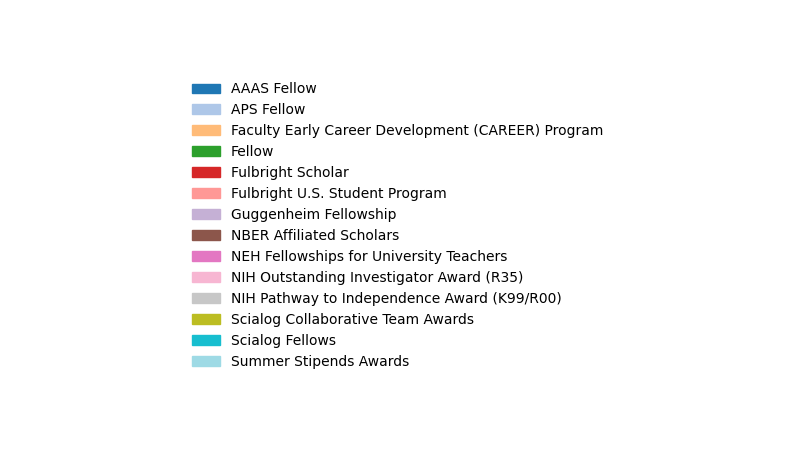

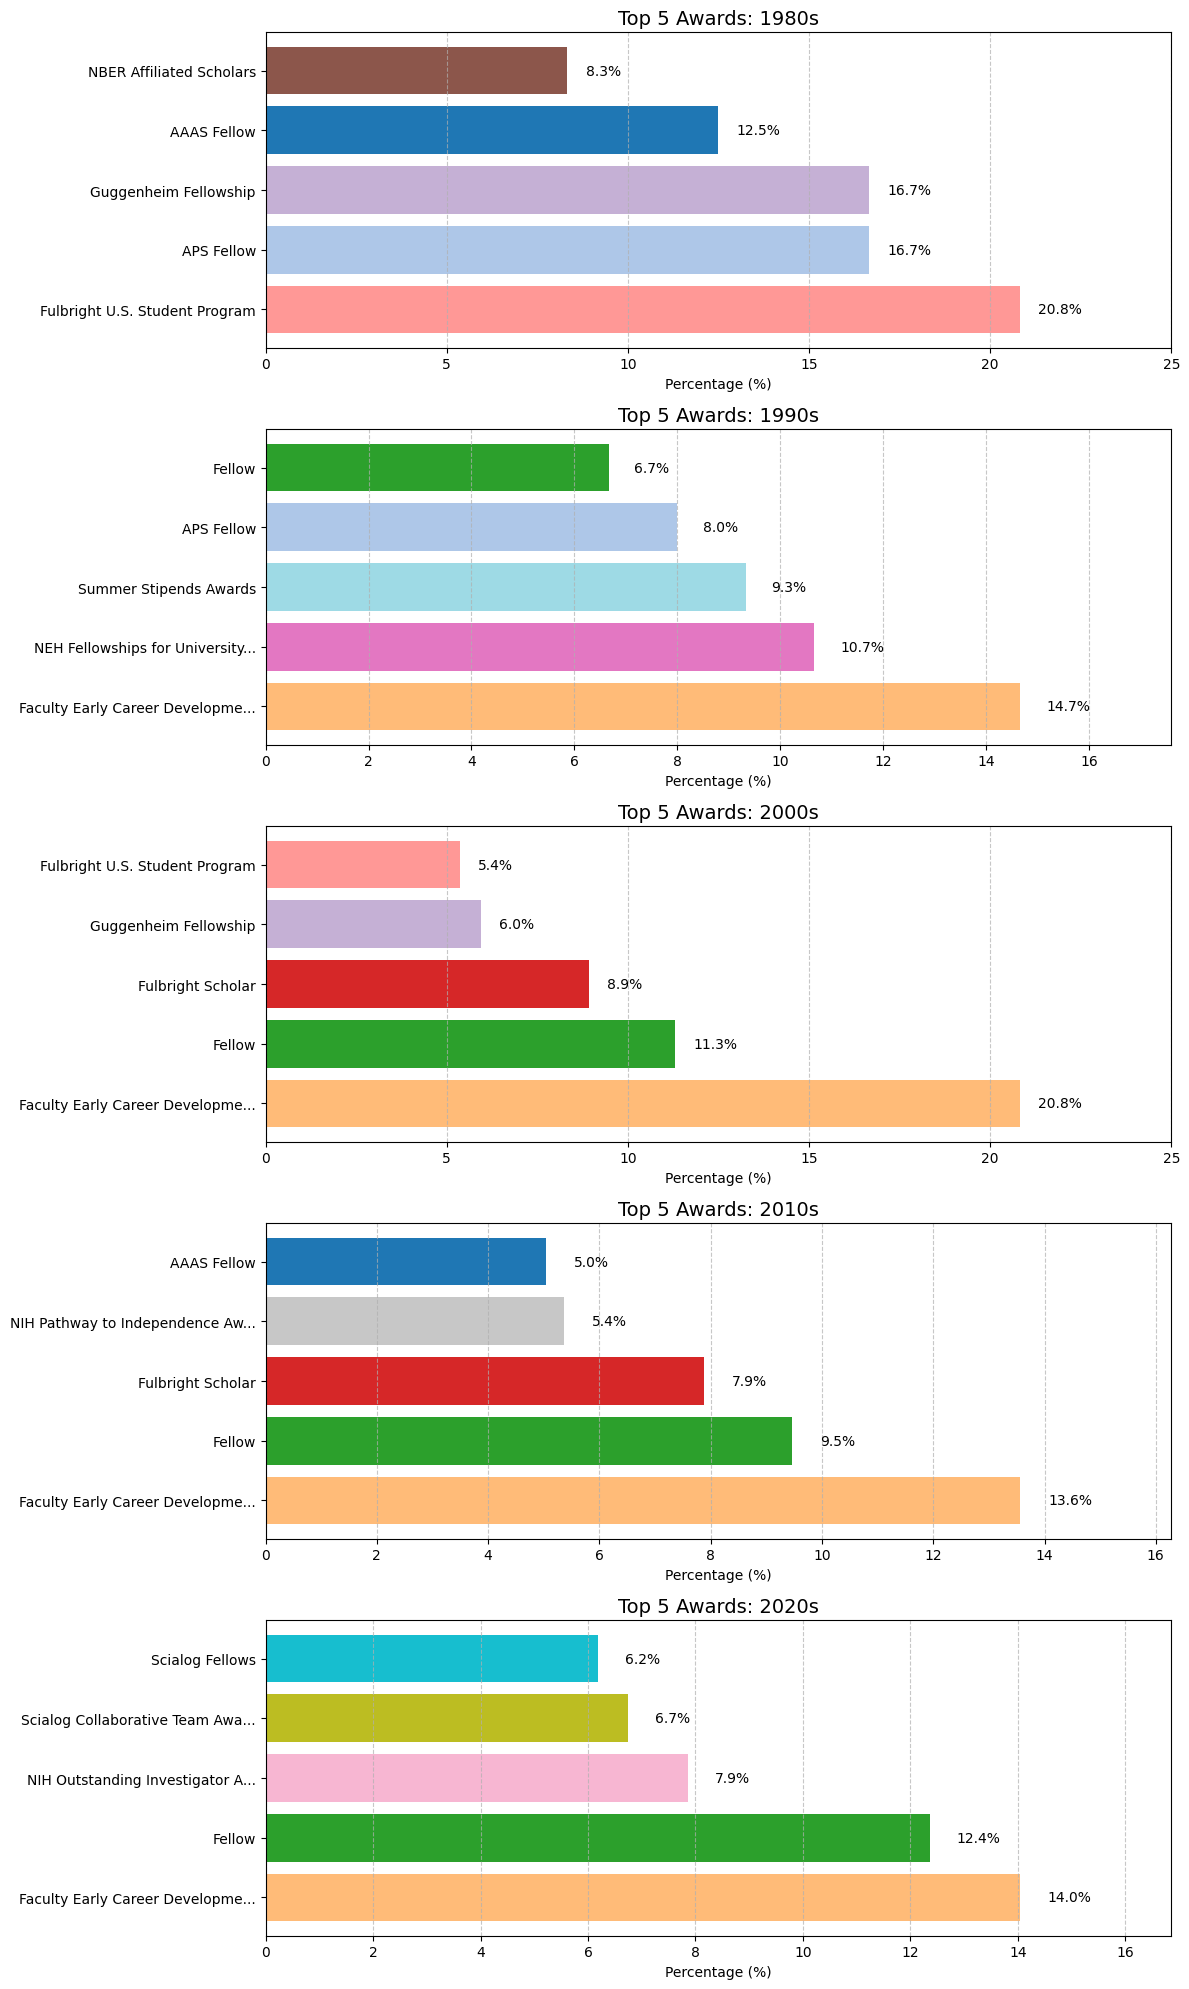

In [34]:
fig, axes = plt.subplots(len(decades), 1, figsize=(12, 4*len(decades)))

for i, decade in enumerate(sorted(decades)):
    ax = axes[i]
    awards = [item['award'] for item in top_awards_by_decade[decade]]
    percentages = [item['percentage'] for item in top_awards_by_decade[decade]]
    short_awards = [award[:30] + '...' if len(award) > 30 else award for award in awards]
    award_colors = [color_map[award] for award in awards]
    bars = ax.barh(short_awards, percentages, color=award_colors)
    
    for bar, pct in zip(bars, percentages):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{pct:.1f}%', va='center')
    
    ax.set_title(f'Top 5 Awards: {decade}', fontsize=14)
    ax.set_xlabel('Percentage (%)')
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.set_xlim(0, max(percentages) * 1.2)

legend_fig, legend_ax = plt.subplots(figsize=(10, len(all_top_awards) * 0.4))
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[award]) for award in sorted(all_top_awards)]
legend_ax.legend(legend_handles, sorted(all_top_awards), loc='center', frameon=False)
legend_ax.axis('off')

plt.figure(fig.number)
plt.tight_layout()

***Award Governing Society and Prestige***

Null hypothesis(H0) : The awarding institution has no relationship with the prestige level of the award.

Alternative hypothesis(HA) : Certain institutions are more likely to grant prestigious awards than others.

In [8]:
import scipy.stats as stats
import pandas as pd

df = pd.read_csv('../dataset/cleaned_ri_matches.csv')

# Not Designated: 0, Prestigious: 1, Highly Prestigious: 2
prestige_mapping = {'Not Designated': 0, 'Prestigious': 1, 'Highly Prestigious': 2}
df['prestige_numeric'] = df['prestige'].map(prestige_mapping)

contingency_table = pd.crosstab(df['awardgoverningsocietyname'], df['prestige_numeric'])

# chi-square stat
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

chi2_stat, p_value, dof

(3504.7642449888986, 4.3513537764537005e-276, 994)

chi sqaure : 3504.7642449888986
p value : 4.3513537764537005e-276
degrees of freedom : 994


The p-value is very small (p<0.001), indicating a statistically significant difference. This means that there is a significant association between the Award Governing Society and the Prestige level of the awards. The results support the alternative hypothesis (HA), suggesting that certain institutions are more likely to grant prestigious awards. In other words, not all institutions distribute awards at the same prestige level, and some organizations tend to grant higher-prestige awards more frequently.

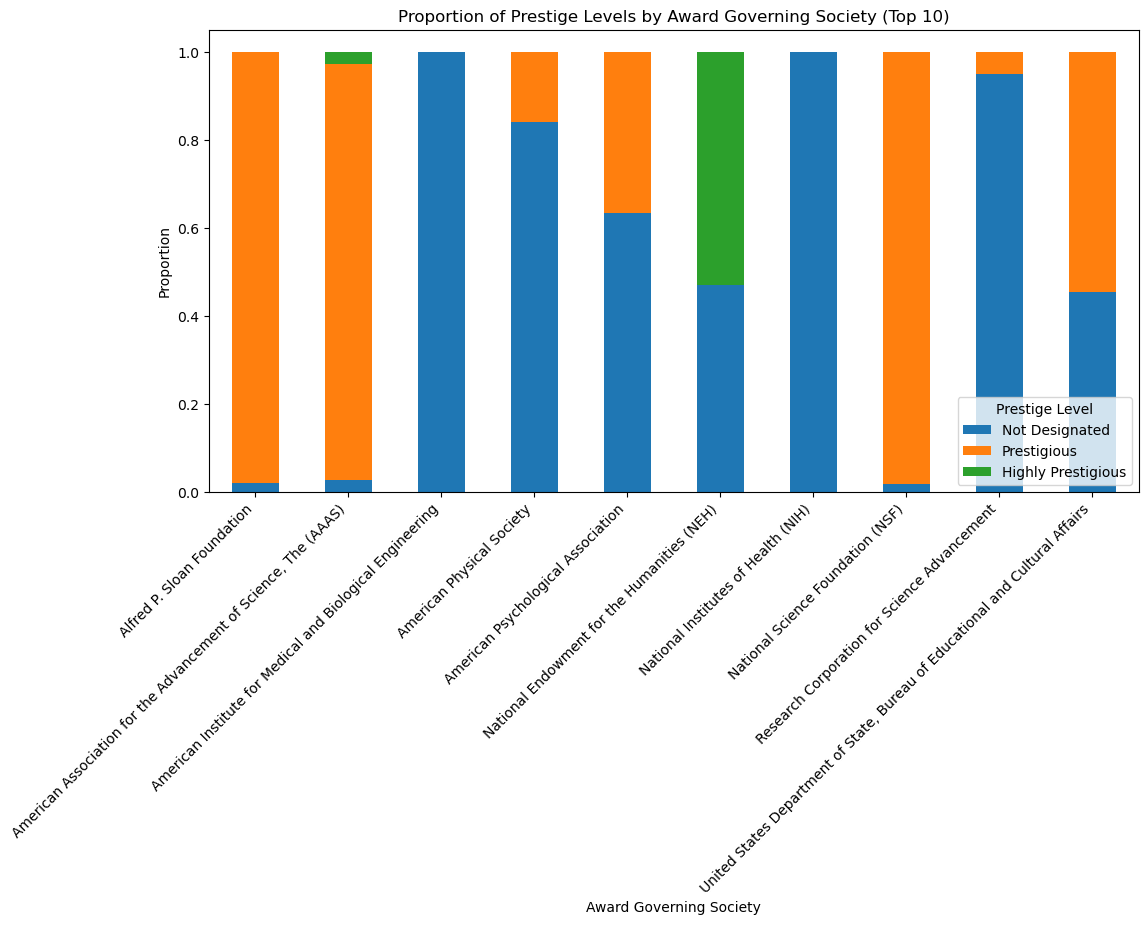

In [9]:
import matplotlib.pyplot as plt

# top 10 societies
top_10_societies = df['awardgoverningsocietyname'].value_counts().head(10).index
df_top = df[df['awardgoverningsocietyname'].isin(top_10_societies)]

# percentage of each societies
prestige_counts = pd.crosstab(df_top['awardgoverningsocietyname'], df_top['prestige_numeric'], normalize='index')

# visualization
ax = prestige_counts.plot(kind='bar', stacked=True, figsize=(12, 6), legend=True)
plt.title("Proportion of Prestige Levels by Award Governing Society (Top 10)")
plt.xlabel("Award Governing Society")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha='right')
plt.legend(["Not Designated", "Prestigious", "Highly Prestigious"], title="Prestige Level")
plt.show()

Certain institutions primarily grant Not Designated (non-prestigious) awards, while others have a higher proportion of Prestigious or Highly Prestigious awards. Notably, some institutions show a tendency to concentrate on awarding prestigious honors.

In [10]:
# filter only Prestigious(1) or Highly Prestigious(2)
prestigious_awards = df[df['prestige_numeric'] > 0]

# calculate the number of awards for each socieites
top_prestigious_df = prestigious_awards.groupby('awardgoverningsocietyname').size().reset_index()

top_prestigious_df.columns = ["Award Governing Society", "Number of Prestigious Awards"]

# filter top 10
top_prestigious_df = top_prestigious_df.sort_values(by="Number of Prestigious Awards", ascending=False).head(10)

print(top_prestigious_df)

                              Award Governing Society  \
68                  National Science Foundation (NSF)   
4                          Alfred P. Sloan Foundation   
89  United States Department of State, Bureau of E...   
9   American Association for the Advancement of Sc...   
55          John Simon Guggenheim Memorial Foundation   
65        National Endowment for the Humanities (NEH)   
13       American Council of Learned Societies (ACLS)   
23                 American Psychological Association   
5               American Academy of Arts and Sciences   
71              Optical Society of America, The (OSA)   

    Number of Prestigious Awards  
68                           114  
4                             48  
89                            48  
9                             36  
55                            33  
65                            26  
13                            23  
23                            19  
5                             16  
71                    

The results of the chi-square test indicate a statistically significant relationship between the Award Governing Society and the Prestige level of the awards (p<0.001). This finding supports the alternative hypothesis, suggesting that certain institutions are more likely to grant prestigious awards than others. The data reveals that some organizations consistently award a higher proportion of prestigious honors, while others primarily distribute non-prestigious awards. This demonstrates that the distribution of award prestige is not uniform across institutions, highlighting a tendency for specific governing bodies to be more associated with prestigious recognition.

***Award Governing Society and Award Name***

Null hypothesis(H0) : There is no tendency for certain institutions to concentrate on awarding specific awards.

Alternative hypothesis(HA) : Certain institutions are more likely to grant specific awards repeatedly.

In [14]:
import scipy.stats as stats

# Award Governing Society & Award Name relationship
contingency_table = pd.crosstab(df['awardgoverningsocietyname'], df['awardname'])

# chi square
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

chi2_stat, p_value, dof

(1121196.064337416, 0.0, 471156)

Chi-Square Statistic: 1121196.064337416.06
p-value: 0.0
Degrees of Freedom (df): 471156

The p-value is extremely small (p<0.001), meaning that the relationship between the Award Governing Society and the Award Name is statistically significant. This supports the alternative hypothesis (HA), indicating that certain institutions are more likely to grant specific awards rather than distributing them randomly. In other words, some governing societies focus on awarding certain specific awards, rather than distributing a variety of awards evenly.

In [16]:
# find the most frequent award names for each society
top_awards_per_society = df.groupby('awardgoverningsocietyname')['awardname'].agg(lambda x: x.value_counts().idxmax())

# find top counts
top_award_counts = df.groupby('awardgoverningsocietyname')['awardname'].agg(lambda x: x.value_counts().max())

top_awards_df = pd.DataFrame({
    "Award Governing Society": top_awards_per_society.index,
    "Most Frequently Given Award": top_awards_per_society.values,
    "Number of Times Given": top_award_counts.values
}).reset_index(drop=True)

# top 10
top_awards_df = top_awards_df.sort_values(by="Number of Times Given", ascending=False).head(10)

print(top_awards_df)

                               Award Governing Society  \
368                  National Science Foundation (NSF)   
470  United States Department of State, Bureau of E...   
71   American Institute for Medical and Biological ...   
358         National Bureau of Economic Research(NBER)   
41   American Association for the Advancement of Sc...   
316          John Simon Guggenheim Memorial Foundation   
366                National Institutes of Health (NIH)   
92                           American Physical Society   
403       Research Corporation for Science Advancement   
317                          John Templeton Foundation   

                           Most Frequently Given Award  Number of Times Given  
368  Faculty Early Career Development (CAREER) Program                    114  
470                                  Fulbright Scholar                     48  
71                                              Fellow                     36  
358                           NBER Affili

The Chi-Square test results indicate a statistically significant relationship between the Award Governing Society and the specific awards they distribute(p <0.001). This finding supports the alternative hypothesis(HA) suggesting that certain institutions tend to concentrate on granting specific awards rather than distributing them randomly.

The analysis reveals that some award governing societies consistently grant the same award multiple times, reinforcing the idea that award distribution is not uniform across institutions. Instead, institutions appear to have a pattern of favoring specific awards.

***Frequency Analysis of Award Recipients***

Null hypothesis(H0) : There is no tendency for individuals to receive multiple awards; most recipients receive only one award.

Alternative hypothesis(HA) : Many individuals tend to receive multiple awards rather than just one.

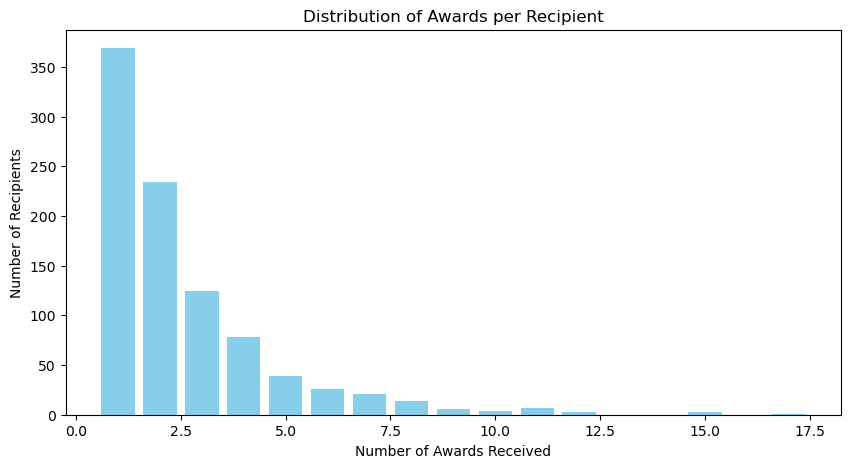

(561, 930, 0.603225806451613)

In [11]:
# calculate Person Name per year
person_award_counts = df['personname'].value_counts()

# distirbution
award_distribution = person_award_counts.value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(award_distribution.index, award_distribution.values, color='skyblue')
plt.xlabel("Number of Awards Received")
plt.ylabel("Number of Recipients")
plt.title("Distribution of Awards per Recipient")
plt.xticks(rotation=0)
plt.show()

# calculate the percentage of the multiple award winners
multiple_award_winners = person_award_counts[person_award_counts > 1].count()
total_recipients = person_award_counts.count()
multiple_award_ratio = multiple_award_winners / total_recipients

multiple_award_winners, total_recipients, multiple_award_ratio

Total Number of Unique Award Recipients: 930
Number of Recipients Who Received More Than One Award: 561
Proportion of Recipients with Multiple Awards: 60.3%

A significant 60.3% of recipients have received multiple awards, indicating that it is common for individuals to receive awards multiple times.

In [13]:
top_award_winners_df = (
    df['personname'].value_counts()
    .reset_index()
    .rename(columns={"index": "Recipient Name", "personname": "Number of Awards Received"})
)

# top 10 frequent winners 
top_award_winners_df = top_award_winners_df.head(10)

print(top_award_winners_df)

  Number of Awards Received  count
0             WONG, JOYCE Y     17
1           BARLOW, DAVID H     15
2                ZHANG, XIN     15
3            KENDI, IBRAM X     15
4         GRINSTAFF, MARK W     12
5             KOPELL, NANCY     12
6         STANLEY, H EUGENE     12
7        BENJAMIN, EMELIA J     11
8       CORRIVEAU, KATHLEEN     11
9         ZAMAN, MUHAMMAD H     11


Additionally, the top 10 most awarded individuals received between 11 and 17 awards.

Since the majority of recipients (over 60%) have received multiple awards, the null hypothesis (H0) is rejected. The results support the alternative hypothesis (HA), indicating that many individuals have a tendency to receive multiple awards rather than just one. This suggests a pattern where certain individuals repeatedly earn recognition, possibly due to continued excellence in their fields or strong institutional affiliations.

***Boston University Affiliation and Award Prestige***

Null hypothesis(H0) : Boston University affiliation has no impact on the prestige level of the awards received.

Alternative hypothesis(HA) : Boston University-affiliated recipients are more or less likely to receive prestigious awards compared to non-affiliated recipients.

In [17]:
# counts BU affilliated recipients
df['is_bu_affiliated'] = df['institutionname'].apply(lambda x: 1 if 'Boston University' in str(x) else 0)

# finding relationships
contingency_table = pd.crosstab(df['is_bu_affiliated'], df['prestige_numeric'])

# chi square stat
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

chi2_stat, p_value, dof


(0.0, 1.0, 0)

Chi-Square Statistic: 0.0
p-value: 1.0
Degrees of Freedom (df): 0

The p-value is 1.0, indicating that there is no statistically significant relationship between Boston University affiliation and award prestige. This means that Boston University-affiliated recipients are neither more nor less likely to receive prestigious awards compared to non-affiliated recipients. The results fail to reject the null hypothesis (H0), suggesting that Boston University affiliation does not influence the prestige level of awards received.

***Award Year and Institution Type***

Null hypothesis(H0) : There is no significant difference in the rate of increase in awards given by different institutions over time.

Alternative hypothesis(HA) : Certain institutions have significantly increased their award distribution rates over time, while others have remained constant or decreased.

In [19]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# counts the number of award for each society
yearly_award_counts = df.groupby(['awardreceivedawardyear', 'awardgoverningsocietyname']).size().reset_index(name='award_count')

pivot_table = yearly_award_counts.pivot(index='awardreceivedawardyear', columns='awardgoverningsocietyname', values='award_count').fillna(0)

# add the number of awards by year
yearly_total_awards = df.groupby('awardreceivedawardyear').size().reset_index(name='total_awards')

X = yearly_total_awards['awardreceivedawardyear']
y = yearly_total_awards['total_awards']

# constant
X = sm.add_constant(X)

# regression
model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           total_awards   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     32.83
Date:                Wed, 05 Mar 2025   Prob (F-statistic):           4.85e-07
Time:                        13:40:54   Log-Likelihood:                -273.06
No. Observations:                  55   AIC:                             550.1
Df Residuals:                      53   BIC:                             554.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                  -2588.2371    459.352     -5.635      0.000   -3509.581   -1666.894
awardreceivedawardyear     1.3184      0.230      5.730      0.000       0.857       1.780
==============================================================================
Omnibus:                       27.205   Durbin-Watson:                   0.493
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.701
Skew:                           1.533   Prob(JB):                     2.18e-12
Kurtosis:                       6.746   Cond. No.                     1.93e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.93e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

awardreceivedawardyear : 1.3184
This means that, on average, approximately 1.32 additional awards are given each year.

p-value : 0
This indicates that the increase in awards over time is statistically significant.

R^2 value: 0.383
This suggests that 38.3% of the variation in total award counts can be explained by the year. However, the remaining 61.7% is likely influenced by other factors, such as institutional policy changes, increased research funding, or external trends.

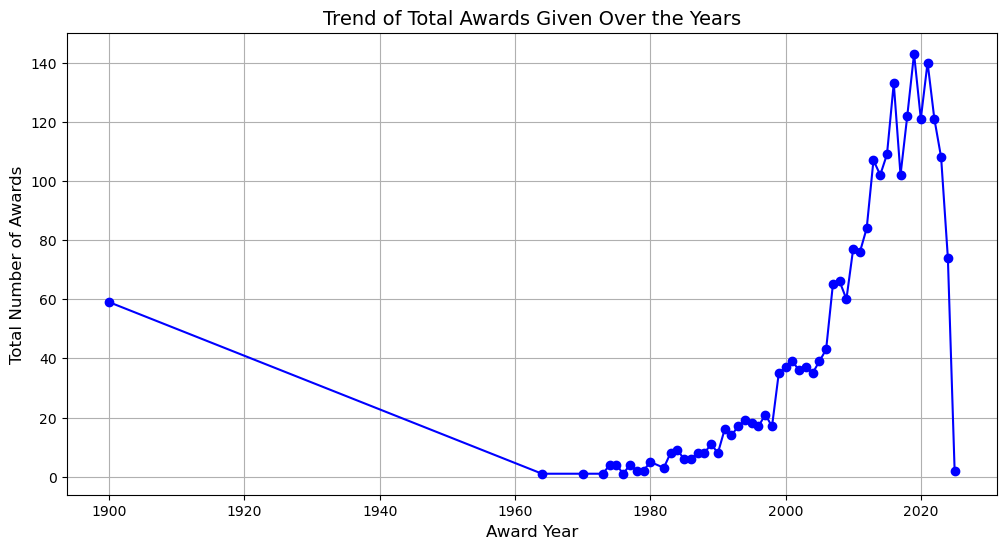

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(yearly_total_awards['awardreceivedawardyear'], yearly_total_awards['total_awards'], marker='o', linestyle='-', color='b')

plt.title("Trend of Total Awards Given Over the Years", fontsize=14)
plt.xlabel("Award Year", fontsize=12)
plt.ylabel("Total Number of Awards", fontsize=12)
plt.grid(True)

plt.show()


In [23]:
import pandas as pd
import statsmodels.api as sm

# awards for each institutions
institution_yearly_awards = df.groupby(['awardreceivedawardyear', 'awardgoverningsocietyname']).size().reset_index(name='award_count')

# top 5 institutions
top_5_institutions = df['awardgoverningsocietyname'].value_counts().head(5).index
institution_yearly_awards_top = institution_yearly_awards[institution_yearly_awards['awardgoverningsocietyname'].isin(top_5_institutions)]

results_list = []

for institution in top_5_institutions:
    data = institution_yearly_awards_top[institution_yearly_awards_top['awardgoverningsocietyname'] == institution]
    
    
    if len(data) > 1: #base case
        X = sm.add_constant(data['awardreceivedawardyear'])
        y = data['award_count']
        
        model = sm.OLS(y, X).fit()
        coef = model.params[1] 
        p_value = model.pvalues[1]  # p-value
        r_squared = model.rsquared  # R^2
        
        results_list.append([institution, coef, p_value, r_squared])

regression_summary_df = pd.DataFrame(results_list, columns=["Institution", "Growth Rate (Coef)", "p-value", "R² Value"])

print(regression_summary_df)


                                         Institution  Growth Rate (Coef)  \
0                  National Science Foundation (NSF)            0.111173   
1  United States Department of State, Bureau of E...            0.059853   
2                National Institutes of Health (NIH)            0.188361   
3                 American Psychological Association            0.048401   
4        National Endowment for the Humanities (NEH)           -0.016148   

    p-value  R² Value  
0  0.000906  0.329709  
1  0.003316  0.232997  
2  0.029218  0.263869  
3  0.132814  0.109342  
4  0.314788  0.036070  


C:\Users\고요\AppData\Local\Temp\ipykernel_79800\2522484980.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = model.params[1]
C:\Users\고요\AppData\Local\Temp\ipykernel_79800\2522484980.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = model.pvalues[1]  # p-value
C:\Users\고요\AppData\Local\Temp\ipykernel_79800\2522484980.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = model.params[1]
C:\Users\고요\AppData

we can see that NSF, NIH, and U.S. Department of State have statistically significant increases in award distribution over time.

The null hypothesis (H0) is rejected, as there are significant differences in award growth rates among institutions. Some institutions, particularly NSF, NIH, and the U.S. Department of State, are increasing their award distribution at a significant rate, while others remain stable or show minimal growth.

This suggests that certain institutions are actively expanding their research funding and recognition programs, while others have a more fixed distribution pattern.